### LISTA 4

Estymatory (metoda momentów i metoda najw wiarygodności)
Wykresy

In [71]:
import scipy.stats as sc
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

In [72]:
ex = sc.lognorm(s=2).expect()

X = np.random.lognormal(sigma=2, size=10000)
mean = np.mean(X)
print(mean, ex)

7.649158834449472 7.389056098805002


2. Rozpatrzmy próbę prostą X1,...,Xn oraz statystykę U = max{X1,...,Xn}. Znajdź rozkład statystyki

U dla próby z następujących rozkładów:

(a) normalnego,

(b) lognormalnego,

(c) Pareto.

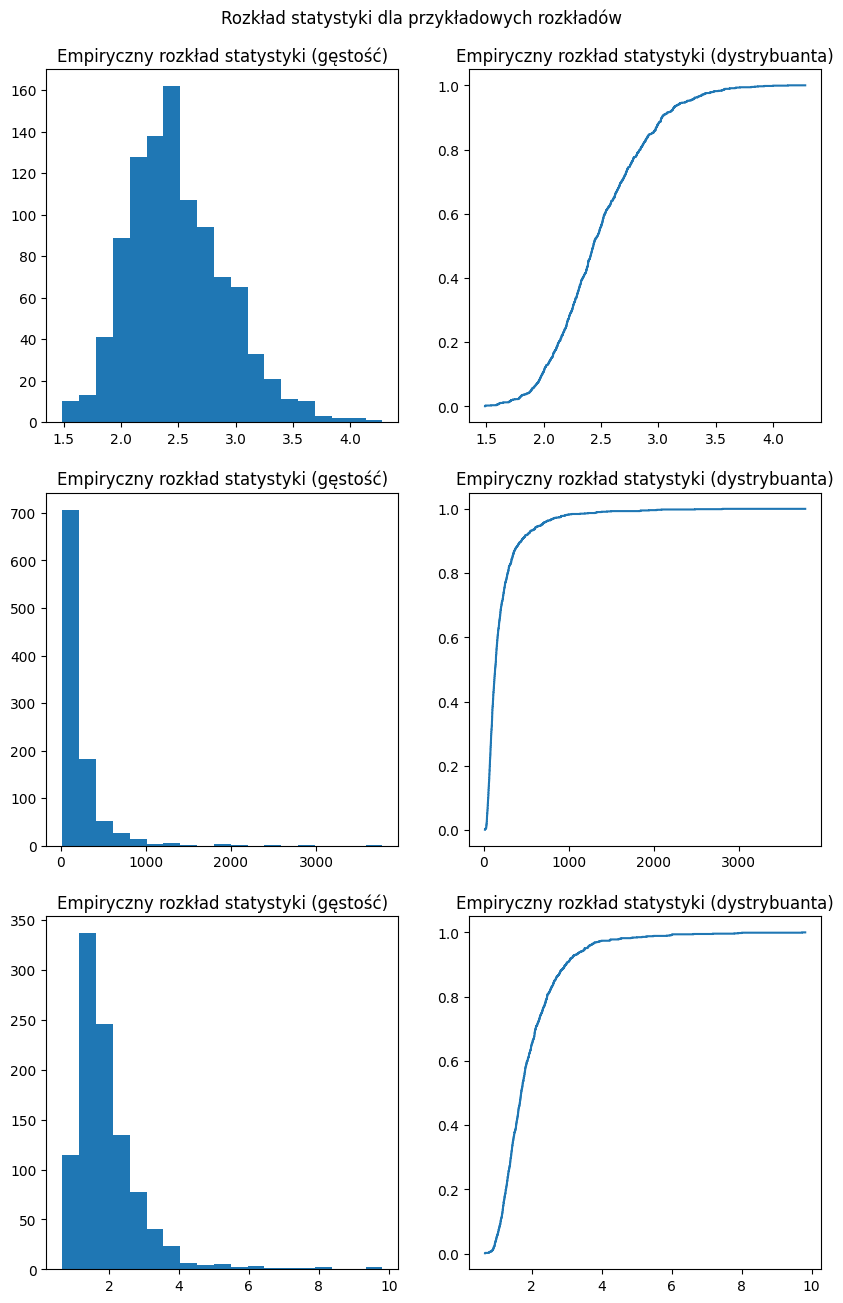

In [73]:
n = 100 # liczba kolumn (obserwacji)

X1 = np.random.normal(size=(1000, n)) # 1000 wierszy, 100 kolumn
Y1 = np.max(X1, 1)

X2 = np.random.lognormal(sigma=2, size=(1000, n)) # 1000 wierszy, 100 kolumn
Y2 = np.max(X2, 1)

X3 = np.random.pareto(5, size=(1000, n)) # 1000 wierszy, 100 kolumn
Y3 = np.max(X3, 1)

Y = [Y1, Y2, Y3]
X = [X1, X2, X3]

fig, axs = plt.subplots(3, 2, figsize=(10, 15))
for i in range(3):
    axs[i, 0].hist(Y[i], bins=np.linspace(np.min(Y[i]), np.max(Y[i]), 20))
    axs[i, 0].set_title('Empiryczny rozkład statystyki (gęstość)')
    y_emp = ECDF(Y[i])
    axs[i, 1].step(y_emp.x, y_emp.y)
    axs[i, 1].set_title('Empiryczny rozkład statystyki (dystrybuanta)')

fig.suptitle('Rozkład statystyki dla przykładowych rozkładów', x=0.5, y=0.95)
fig.subplots_adjust(top=0.91)
# fig.text()
#plt.tight_layout()
plt.show()

### Zadanie 6

In [ ]:
from scipy.optimize import minimize
tab = sc.pareto.rvs(b=2,loc=5, size=10000)

def logL(tab, a, x0):
    #if a <= 0: return -1e10
    #if np.any(tab < x0+1): return -1e10
    return np.sum(sc.pareto.logpdf(x=tab,b=a,loc=x0))

res = minimize(
    fun=lambda params: -logL(tab, params[0], params[1]), # max(logx) -> min(-logx) bo log to fkcja rosnaca
    # początkowe wartości parametrów optymalizacji:
    # params[0] -> a
    # params[1] -> x0
    x0=[67, min(tab)-1],
    bounds=((1e-6, 1e6), (None, min(tab)-1))
    # ograniczenia parametrów:
    # 1e-6 <= params[0] <= 1e6
    # params[1] <= min(tab)-1
)
print(res.x) 

[2.0193226  5.00013592]


### Zadanie 8

Niech X1,...,X2n+1 będzie próbą prostą z rozkładu normalnego z nieznaną średnią µ oraz wariancją
σ2 = 1. Rozważmy dwa estymatory parametru µ: próbkowa średnia oraz próbkowa mediana. Aby
porównać esymatory wysumuluj próbę ze standardowego rozkładu normalnego i znajdź błąd śred
niokwadratowy dla obu estymatorów. Powtórz tą procedurę 100 razy aby uzyskać próbkową wartość
oczekiwaną błędu estymacji. Jakie wnioski możesz wyciągnąć na podstawie tego eksperymentu?

In [ ]:
a = 5
X = np.random.normal(loc=a, scale=1, size=(100, 1000)) # 100 próbek po 1000 wartości z rozkładu normalnego
median = np.median(X, axis=1)
mean = np.mean(X, axis=1)

mse1 = np.mean((median-a)**2)
mse2 = np.mean((mean-a)**2)


print(mse1, mse2)

## wniosek: mse2 < mse1 => mean lepsze

0.0016626689389592536 0.0009787444618461108


10. Niech X1,...,X7 będzie próbą prostą z rozkładu normalnego ze średnią µ i wariancją σ2. 

Rozpatrzmy dwa estymatory µ

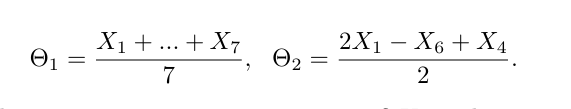

4.987540909933463 4.943043555849208
0.14343173043564528 1.4337070013766064


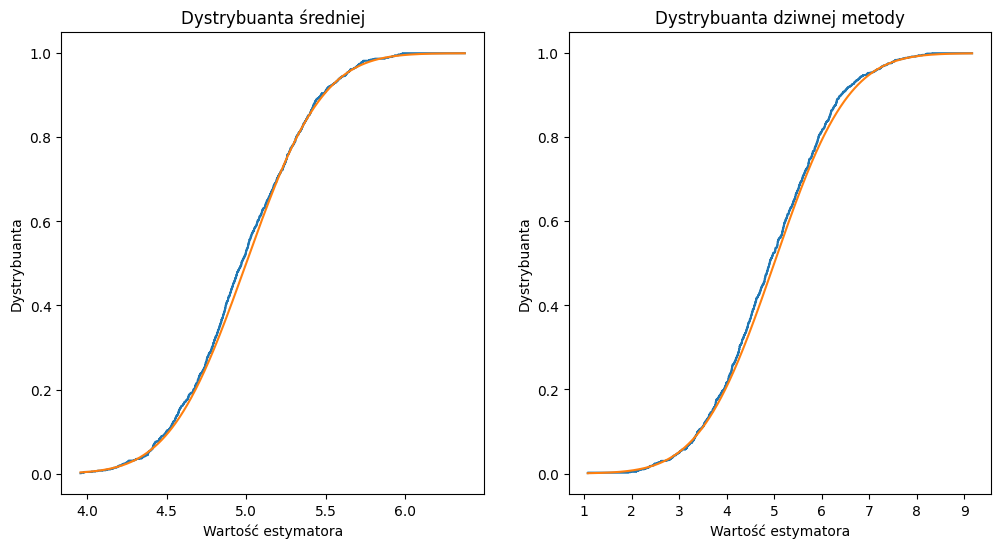

In [87]:
n = 1000
X = np.random.normal(size=(n, 7), loc=5)
theta_1 = np.mean(X, axis=1)
theta_2 = [0.5*(2*X[k][0] - X[k][5] + X[k][3]) for k in range(n)]

print(np.mean(theta_1), np.mean(theta_2))
print(np.var(theta_1), np.var(theta_2))
y1_ecdf = ECDF(theta_1)
y2_ecdf = ECDF(theta_2)

x1 = np.linspace(min(theta_1), max(theta_1), 1000)
y1 = sc.norm.cdf(x1, loc=5, scale=1/np.sqrt(7))

x2 = np.linspace(min(theta_2), max(theta_2), 1000)
y2 = sc.norm.cdf(x2, loc=5, scale=np.sqrt(3/2))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].step(y1_ecdf.x, y1_ecdf.y)
axs[0].plot(x1, y1)

axs[1].step(y2_ecdf.x, y2_ecdf.y)
axs[1].plot(x2, y2)

for i in range(2):
    axs[i].set_xlabel('Wartość estymatora')
    axs[i].set_ylabel('Dystrybuanta')
### xlim, ylim - ograniczenia osi

axs[0].set_title('Dystrybuanta średniej')
axs[1].set_title('Dystrybuanta dziwnej metody')
plt.show()